## **Introduction to Integer Programming and Applications with Julia**

<table>
  <tr>
    <td>Chapter</td>
    <td>7 - Lagrangian Relaxation</td>
  </tr>
  <tr>
    <td>Section</td>
    <td>7.2.2 - Solving Lagrangian relaxation for model E using Julia</td>
  </tr>
  <tr>
    <td>Author(s)</td>
    <td>Luiz Henrique Nogueira Lorena</td>
  </tr>
</table>

-------------- Starting Lagrangian Relaxation --------------
Iter. |    λ    |  Lower Bound  |   Upper Bound  |   Gap
------------------------------------------------------------
    1 |  0.0000 |        0.0000 |        17.0000 |    17.000
   10 |  5.1510 |       11.8490 |        17.0000 |     5.151
   20 |  3.4105 |       14.5131 |        17.0000 |     2.487
   30 |  2.6241 |       14.5474 |        17.0000 |     2.453
   40 |  1.6741 |       14.6562 |        17.0000 |     2.344
------------------------------------------------------------
Lagrangian relaxation stopped. No improvement in LB for 10 iterations.
-------------------------- Results -------------------------
Optimal Dual Solution (λ = 2.34): 14.66
Optimal Primal Solution: x = [1, 1] with objective value 17.00
Duality gap: 17.00 - 14.66 = 2.34


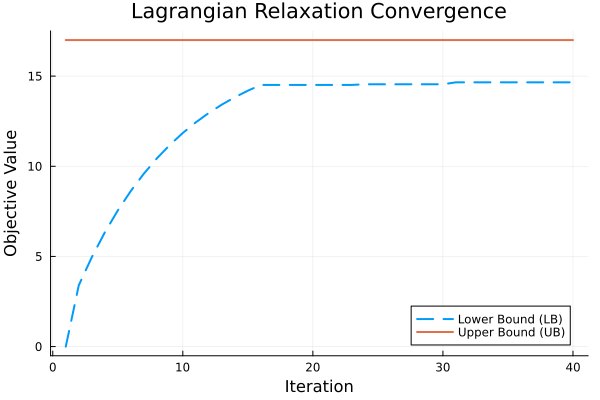

In [13]:
using JuMP   # For mathematical programming
using HiGHS  # HiGHS solver
using Printf # For formatted output

# Utility functions for plotting bounds convergence
include("utils/lr_utils.jl")

# Function to solve the original integer program exactly
function solve_exact()
    # Create the model
    model =  JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Define binary variables
    @variable(model, x[1:2], Bin)
    # Define the objective function
    @objective(model, Min, 7 * x[1] + 10 * x[2])
    # Define the constraint
    @constraint(model, 3 * x[1] + 5 * x[2] >= 7)
    # Solve the model
    JuMP.optimize!(model)
    # Get results
    x_opt =  JuMP.value.(x)
    obj_value = JuMP.objective_value(model)
    return x_opt, obj_value
end

# Function to perform Lagrangian relaxation
function solve_lagrangian(;iteration_max = 100)
    # Initialize variables
    x = [0, 0]  # Initial solution
    λ = 0.0     # Initial Lagrange multiplier
    λ_best = λ  # To track the best λ found
    α = 0.1     # Step size
    θ = 0.8     # A factor to update multiplier (Held-Karp)
    LB = -Inf   # Best lower bound found so far
    UB = Inf    # Best upper bound found so far
    LB_history = Float64[] # Store LB for plotting
    UB_history = Float64[] # Store UB for plotting

    # Logic to stop if no improvement in UB
    no_improve_limit = 10
    no_improve_counter = 0

    println("-"^14," Starting Lagrangian Relaxation ", "-"^14)
    println("Iter. |    λ    |  Lower Bound  |   Upper Bound  |   Gap")
    println("-"^60)

    for iteration in 1:iteration_max
        # Compute primal solution at current λ
        x[1] = (7 - 3 * λ) > 0 ? 1 : 0
        x[2] = (10 - 5 * λ) > 0 ? 1 : 0

        # Lagrangian dual value
        zL = 7 * λ + min(0, 7 - 3 * λ) + min(0, 10 - 5 * λ)
      
        # Check for improvement in LB
        if zL > LB 
            LB = zL
            λ_best = λ              # Update the best λ found
            no_improve_counter = 0  # Reset counter
        else
            no_improve_counter += 1
            # Check if we have reached the limit of no improvement
            if no_improve_counter >= no_improve_limit
                println("-"^60)
                println("Lagrangian relaxation stopped. ",
                        "No improvement in LB for $no_improve_limit iterations.")
                break
            end
        end

        # Feasible primal value
        if 3 * x[1] + 5 * x[2] >= 7
            zP = 7 * x[1] + 10 * x[2]
            UB = min(UB, zP)
        end
        
        # Store LB and UB values for plotting
        push!(LB_history, LB)
        push!(UB_history, UB)

        # Print iteration details
        if iteration % 10 == 0 || iteration == 1
            @printf("%5d | %7.4f | %13.4f | %14.4f | %9.3f\n", iteration, λ, LB, UB, UB - LB)
        end

        # Subgradient
        s = 7 - 3 * x[1] - 5 * x[2]
        
        # Update step size (Diminishing step size)
        α = θ * ((UB - LB) / (s^2 + 1e-8))
        
        # Update λ (project onto λ ≥ 0)
        λ = max(0, λ - α * s)
    end
    
    # Solve exactly to find the optimal value
    xO, zO = solve_exact()

    # Print results
    println("-"^26, " Results ", "-"^25)
    @printf("Optimal Dual Solution (λ = %4.2f): %4.2f\n", λ_best, LB)
    @printf("Optimal Primal Solution: x = [%d, %d] with objective value %4.2f\n", xO[1], xO[2], zO)
    @printf("Duality gap: %4.2f - %4.2f = %4.2f\n", zO, LB, zO - LB)

    # Plot convergence history
    plot_convergence("Lagrangian Relaxation Convergence", LB_history, UB_history)
end

solve_lagrangian(iteration_max = 100)

<table>
  <tr>
    <td>Chapter</td>
    <td>7 - Lagrangian Relaxation</td>
  </tr>
  <tr>
    <td>Section</td>
    <td>7.3.1.1 - Solving Lagrangian relaxation for PMP using Julia</td>
  </tr>
  <tr>
    <td>Author(s)</td>
    <td>Luiz Henrique Nogueira Lorena</td>
  </tr>
</table>

----------- Starting Lagrangian Relaxation -----------
Iter.  |   Lower Bound   |   Upper Bound   |   Gap (%)
------------------------------------------------------
     1 |           0.000 |       26450.804 |   100.000
    10 |        7088.505 |       26450.804 |    73.201
    20 |       15640.313 |       26450.804 |    40.870
    30 |       17461.484 |       22373.178 |    21.953
    40 |       18442.358 |       22373.178 |    17.569
    50 |       18803.624 |       22373.178 |    15.955
    60 |       18897.387 |       22373.178 |    15.536
    70 |       18897.387 |       22373.178 |    15.536
    80 |       18897.387 |       22373.178 |    15.536
    90 |       19061.685 |       22373.178 |    14.801
   100 |       19061.685 |       22373.178 |    14.801
   110 |       19061.685 |       22373.178 |    14.801
   120 |       19061.685 |       22373.178 |    14.801
   130 |       19061.685 |       22373.178 |    14.801
   140 |       19061.685 |       22373.178 |    14.801
   150 |  

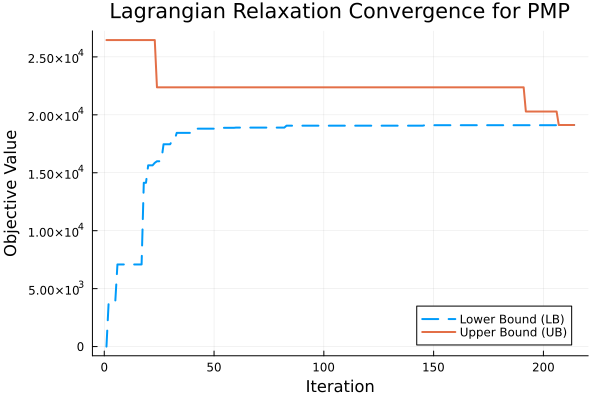

In [12]:
using JuMP          # For mathematical programming
using HiGHS         # HiGHS solver
using CSV           # For reading CSV files
using Distances     # Distance computations
using LinearAlgebra # For norm calculations
using Printf        # For formatted output

# Utility functions for plotting bounds convergence
include("utils/lr_utils.jl")

# Data structure to hold the p-median problem data
struct PMedianData
    D::Matrix{Float64} # Distance matrix
    p::Int             # Number of facilities
    n::Int             # Number of clients/locations
    # Constructor
    function PMedianData(file_path::String; p::Int)
        # Load latitude and longitude data
        coordinates = CSV.read(file_path, CSV.Tables.matrix, header=true)
        # Compute Haversine distance matrix
        D = pairwise(Haversine(), coordinates, dims=1)
        return new(D, p, size(D, 1))
    end
end

# Function to solve the PMP exactly
function solve_pmp_exact(data::PMedianData)
    # Range for points
    N = 1:data.n
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, x[i in N, j in N], Bin)  
    # Objective: Minimize total distance
    @objective(model, Min, sum(data.D[i,j] * x[i,j] for i in N, j in N))
    # Constraint: Exactly p facilities opened
    @constraint(model, sum(x[j,j] for j in N) == data.p)
    # Constraint: Each customer assigned to one facility
    @constraint(model, [i in N], sum(x[i,j] for j in N) == 1)
    # Constraint: Assignment only to open facilities
    @constraint(model, [i in N, j in N], x[i,j] <= x[j,j])
    # Run the solver 
    JuMP.optimize!(model)
    # Return the optimal value
    if JuMP.termination_status(model) == JuMP.OPTIMAL
        return JuMP.objective_value(model)
    else
        error("Optimal solution not found.")
    end
end

# Main function to solve PMP using Lagrangian Relaxation
function solve_pmp_lagrangian(file_path; p = 3, iteration_max = 100, gap_tolerance = 1e-6)
    # Load problem data
    data = PMedianData(file_path, p = p)

    # Auxiliary variables
    N = 1:data.n
    
    # Algorithm Initialization
    λ = zeros(data.n)      # Initial Lagrange multipliers
    θ = 2.0                # A factor to update multiplier (Held-Karp)
    LB = -Inf              # Best lower bound found so far
    UB = Inf               # Best upper bound found so far
    LB_history = Float64[] # Store LB for plotting
    UB_history = Float64[] # Store UB for plotting

    # Logic to reduce θ if no improvement in LB
    no_improve_limit = 10
    no_improve_counter = 0

    println("-"^11," Starting Lagrangian Relaxation ", "-"^11)
    println("Iter.  |   Lower Bound   |   Upper Bound   |   Gap (%)")
    println("-"^54)

    for iteration in 1:iteration_max
        # --- Step 1: Lower Bound ---
        
        # 1a. Calculate attractiveness of each facility
        costs = data.D .- λ
        facility_scores = vec(sum(min.(0.0, costs), dims=1))
        
        # 1b. Select the p best facilities (smallest value)
        chosen = sortperm(facility_scores)[1:data.p]

        # 1c. Calculate the LB
        current_LB = sum(facility_scores[chosen]) + sum(λ)

        # 1d. Update the best LB
        if current_LB > LB
            LB = current_LB
            no_improve_counter = 0
        else
            no_improve_counter += 1
            # Reduce θ if progress stalls
            if no_improve_counter >= no_improve_limit
                # Reset counter
                no_improve_counter = 0
                # Reduce θ to allow for finer adjustments
                θ = max(0.5, θ * 0.5)
            end
        end

        # 1e. Store LB for plotting
        push!(LB_history, LB)

        # --- Step 2: Upper Bound (Heuristic) ---

        # 2a. For each customer, assign to the closest facility
        current_UB = sum([minimum(data.D[i, chosen]) for i in N])

        # 2b. Update the best UB
        UB = min(UB, current_UB)

        # 2c. Store UB history
        push!(UB_history, UB)

        # 2d. Stopping Criterion
        gap = isfinite(UB) ? abs(UB - LB) / (UB + 1e-10) : Inf
        if gap < gap_tolerance
            @printf("%6d | %15.3f | %15.3f | %9.3f\n", iteration, LB, UB, 100 * gap)
            println("-"^54)
            @printf("Convergence achieved at iteration %d with gap %.3f%%.\n", iteration, 100 * gap)
            break
        end

        # --- Step 3: Update Multipliers ---

        # 3a. Calculate the subgradient s_i = 1 - sum(x_ij)
        x_relaxed = (costs[:, chosen] .< 0)
        s = 1.0 .- vec(sum(x_relaxed, dims=2))
        
        # 3b. Determine the step size α_k (Held-Karp style)
        α = θ * (abs(UB - LB) / (norm(s)^2 + 1e-8))

        # 3c. Update the multipliers
        λ .+= α .* s

        # Print iteration details
        if iteration % 10 == 0 || iteration == 1
            @printf("%6d | %15.3f | %15.3f | %9.3f\n", iteration, LB, UB, 100 * gap)
        end
    end

    # Final summary and Exact solve for comparison
    exact_objective = solve_pmp_exact(data)
    println("-"^54,"\nSolving exact PMP for comparison...")
    @printf("Final LB: %.3f | Exact: %.3f | Duality Gap: %.3f%%\n", LB, exact_objective, 100 * abs(exact_objective - LB)/exact_objective)

    # Plot convergence history
    plot_convergence("Lagrangian Relaxation Convergence for PMP", LB_history, UB_history)
end

# Example usage
solve_pmp_lagrangian("data/coordinates.csv", p = 3, iteration_max = 300)

<table>
  <tr>
    <td>Chapter</td>
    <td>7 - Lagrangian Relaxation</td>
  </tr>
  <tr>
    <td>Section</td>
    <td>7.4.3 - Solving LagClus for MISP using Julia</td>
  </tr>
  <tr>
    <td>Author(s)</td>
    <td>Luiz Henrique Nogueira Lorena</td>
  </tr>
</table>

----------- Starting Lagrangian Relaxation -----------
Iter.  |   Lower Bound   |   Upper Bound   |   Gap (%)
------------------------------------------------------
     1 |           3.000 |           4.000 |    25.000
     2 |           3.000 |           3.200 |     6.250
     3 |           3.000 |           3.040 |     1.316
     4 |           3.000 |           3.008 |     0.266
     5 |           3.000 |           3.002 |     0.053
     6 |           3.000 |           3.000 |     0.011
     7 |           3.000 |           3.000 |     0.002
     8 |           3.000 |           3.000 |     0.000
Convergence achieved at iteration 9 with gap 0.000%.
------------------------------------------------------
Solving exact MISP for comparison...
Final UB: 3.0000 | Exact: 3.0000 | Duality Gap: 0.000%


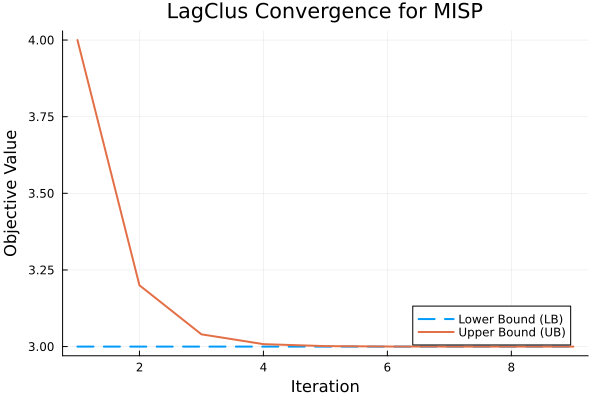

In [1]:
using JuMP          # For mathematical programming
using HiGHS         # HiGHS solver
using Graphs        # Graphs package
using Metis         # For graph partitioning
using LinearAlgebra # For norm calculation
using Printf        # For formatted output

# Utility functions for plotting bounds convergence
include("utils/lr_utils.jl")
 
# Function to solve MISP exactly
function solve_misp_exact(graph)
    V = 1:Graphs.nv(graph)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, x[v in V], Bin)
    # Objective: Maximize sum of x[i]
    @objective(model, Max, sum(x[v] for v in V))
    # Constraints: x[u] + x[v] <= 1 for each edge (u,v)
    for e in Graphs.edges(graph)
        u = Graphs.src(e)
        v = Graphs.dst(e)
        @constraint(model, x[u] + x[v] <= 1)
    end
    # Run the solver
    JuMP.optimize!(model)
    # Return the optimal value
    if JuMP.termination_status(model) == JuMP.OPTIMAL
        return JuMP.objective_value(model)
    else
        error("Optimal solution not found.")
    end
end

# Function to partition graph using Metis
function metis_partition(graph, k)
    partition = Metis.partition(graph, k)
    clusters = [Int[] for _ in 1:k]
    for v in 1:Graphs.nv(graph)
        push!(clusters[partition[v]], v)
    end
    cut_edges = []
    for (e_id, e) in enumerate(Graphs.edges(graph))
        u = Graphs.src(e)
        v = Graphs.dst(e)
        if partition[u] != partition[v]
            push!(cut_edges, (u,v))
        end
    end
    return clusters, cut_edges
end

# Function to create a feasible solution from Lagrangian solution
function create_feasible_solution(graph, lag_solution)
    n = Graphs.nv(graph)
    feasible_solution = copy(lag_solution)
    # Greedily remove conflicts
    for u in 1:n
        if feasible_solution[u] == 1
            for v in Graphs.neighbors(graph, u)
                if feasible_solution[v] == 1
                    # Break tie by degree (drop node with higher degree)
                    if Graphs.degree(graph, u) ≥ Graphs.degree(graph, v)
                        feasible_solution[u] = 0
                    else
                        feasible_solution[v] = 0
                    end
                end
            end
        end
    end
    return feasible_solution
end

# Function to solve Lagrangian subproblem for a cluster
function solve_misp_lagrangian(graph, cluster, λ, solution)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, x[cluster], Bin)
    # Objective: Maximize sum of x[i]
    obj = sum(x[i] for i in cluster)
    # Add λ terms to objective and constraints
    for u in cluster
        for v in Graphs.neighbors(graph, u)
            if v in cluster
                if u < v
                    @constraint(model, x[u] + x[v] <= 1)
                end
            else
                if u < v
                    obj -= λ[(u,v)] * x[u]
                else
                    obj -= λ[(v,u)] * x[u]
                end
            end
        end
    end
    @objective(model, Max, obj)
    # Run the solver
    JuMP.optimize!(model)
    # Get the values of the decision variables
    for i in cluster
        solution[i] = JuMP.value(x[i])
    end
    return JuMP.objective_value(model)
end

# Main function to solve MISP using LagClus
function solve_misp_lagclus(graph; iteration_max = 2, k = 2, gap_tolerance = 1e-6)
    
    # Get Metis partition
    clusters, cut_edges = metis_partition(graph, k)
    
    # Initialize Lagrange multipliers and subgradient for cut edges
    λ = Dict{Tuple{Int,Int}, Float64}()
    s = Dict{Tuple{Int,Int}, Float64}()
    for (u,v) in cut_edges
        λ[(u,v)] = 0.0
        s[(u,v)] = 0.0
    end
    
    # Initialize parameters
    θ = 0.8   # A factor to update multiplier (Held-Karp)
    LB = -Inf # Upper bound
    UB = Inf  # Lower bound
    LB_history = [] # Lower bound history
    UB_history = [] # Upper bound history
    
    # Logic to reduce θ if no improvement in LB
    no_improve_limit = 10
    no_improve_counter = 0
    
    # Print header
    println("-"^11," Starting Lagrangian Relaxation ", "-"^11)
    println("Iter.  |   Lower Bound   |   Upper Bound   |   Gap (%)")
    println("-"^54)
    
    # Store the best feasible solution found
    best_feasible_solution = zeros(Graphs.nv(graph))
    
    # Main loop
    for iteration in 1:iteration_max
        # --- Step 1: Upper Bound ---
        
        # 1a. Solve Lagrangian subproblems
        lag_objective = 0.0
        lag_solution = zeros(Graphs.nv(graph))
        
        # Solve for each cluster
        for cluster in clusters
            lag_objective += solve_misp_lagrangian(graph, cluster, λ, lag_solution)
        end
        
        # Add penalty for cut edges
        lag_objective += sum(λ[(u,v)] for (u,v) in cut_edges)
        
        # 1b. Update UB (Upper bound)
        if lag_objective < UB
            UB = lag_objective
            no_improve_counter = 0
        else
            no_improve_counter += 1
            # Reduce θ if progress stalls
            if no_improve_counter >= no_improve_limit
                # Reset counter
                no_improve_counter = 0
                # Reduce θ to allow for finer adjustments
                θ = max(0.5, θ * 0.5)
            end
        end
        push!(UB_history, UB)
        
        # --- Step 2: Lower Bound (Feasible Solution) ---
        
        # 2a. Create a feasible solution by greedy repair
        feasible_solution = create_feasible_solution(graph, lag_solution)
        current_LB = sum(feasible_solution)
        
        # 2b. Update the best lower bound if this heuristic solution is better
        if current_LB > LB
            LB = current_LB    
            best_feasible_solution = copy(feasible_solution)
        end

        # 2c. Store upper bound history
        push!(LB_history, LB)
        
        # 2d. Stopping Criterion
        gap = isfinite(UB) ? abs(UB - LB) / (UB + 1e-10) : Inf
        if isfinite(gap) && gap <= gap_tolerance
            @printf("Convergence achieved at iteration %d with gap %.3f%%.\n", iteration, 100 * gap)
            break
        end
        
        # --- Step 3: Update Multipliers ---
        
        # 3a. Calculate Lagrange multipliers
        s_norm = []
        for (u,v) in cut_edges
            s[(u,v)] = lag_solution[u] + lag_solution[v] - 1
            push!(s_norm, s[(u,v)])
        end
        
        # 3b. Adaptive step-size update (Held-Karp)
        α = θ * ((UB - LB) / (norm(s_norm)^2 + 1e-8))
        
        # 3c. Update the multipliers
        for (u,v) in cut_edges
            λ[(u,v)] = max(0.0, λ[(u,v)] + α * s[(u,v)])
        end

        # Print iteration results
        @printf("%6d | %15.3f | %15.3f | %9.3f\n", iteration, LB, UB, 100 * gap)
    end
    
    # Final summary and Exact solve for comparison
    exact_objective = solve_misp_exact(graph)
    println("-"^54)
    println("Solving exact MISP for comparison...")
    @printf("Final UB: %.4f | Exact: %.4f | Duality Gap: %.3f%%\n", UB, exact_objective, 100 * abs(exact_objective- UB)/exact_objective)
    
    # Plot convergence history
    plot_convergence("LagClus Convergence for MISP", LB_history, UB_history)
end

# Create graph
edges = [(1,2), (1,7), (1,8), (2,3), 
         (2,8), (3,5), (3,6), (3,7), 
         (4,5), (4,7), (5,6), (7,8)]
graph = Graph(8)
for (u,v) in edges
    add_edge!(graph, u, v)
end

# Example usage
solve_misp_lagclus(graph, iteration_max = 200, k=2)